In [1]:
import matplotlib.pyplot as plt
import sys
import os
import importlib

In [2]:
# Add the parent directory to the path to import src as a package
sys.path.insert(0, os.path.abspath('..'))
from src import dataloader
importlib.reload(dataloader)
from src import utils
from src import export
importlib.reload(export)
from src.export import export_to_xarray 

%matplotlib inline 
plot_flag = False

In [3]:
import xarray as xr

In [4]:
def plot_data_with_margin(multimodal_data, selected_event, time_margin, member, selected_channels):
    ev = multimodal_data.events[selected_event]
    event_start = ev['start']
    event_end = ev['start'] + ev['duration']

    recording_start = multimodal_data.data['time'].min()
    recording_end = multimodal_data.data['time'].max()

    selected_time = [
        max(recording_start, event_start - time_margin),
        min(recording_end, event_end + time_margin),
    ]
    print(f"Dyad ID: {multimodal_data.id}")
    print(f"Event '{selected_event}' starts at {event_start:.2f}s and ends at {event_end:.2f}s")
    print(f"Selected time range with ±{time_margin}s margin: {selected_time[0]:.2f}s to {selected_time[1]:.2f}s")

    time, channels_EEG, data_EEG = multimodal_data.get_signals(
        mode='EEG',
        member=member,
        selected_channels=selected_channels,
        selected_times=selected_time
    )
    print(f"Retrieved EEG data shape: {data_EEG.shape}")  # Should be (n_channels, n_samples)
    time, channels, diode_data = multimodal_data.get_signals(
                        mode='diode', 
                        selected_channels=['diode'],
                        selected_times=selected_time
                    )  
    plt.figure(figsize=(20, 3), dpi=300)
    for i, ch_name in enumerate(channels_EEG):
        plt.plot(time, data_EEG[:,i], label=ch_name)
    plt.plot(time, diode_data[:,0]*200, label='diode', color='k', linewidth=2)
    plt.axvline(x=event_start, color='r', linestyle='--', label='Event Start')
    plt.axvline(x=event_end, color='g', linestyle='--', label='Event End')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (µV)')
    plt.title(f'EEG Signals for Selected Channels between {selected_time[0]:.2f}s and {selected_time[1]:.2f}s during {selected_event} Event')
    plt.legend()
    plt.show()
    return 



# Select parameters

In [5]:
time_margin = 10 # seconds
member = 'ch' #'cg'
selected_modality = 'EEG' # choose 'EEG', 'ECG', 'ET', 'IBI', 'RMSSD' or 'diode' for modality to export to xarray (diode is the reference for checking the correctness of event slicing)
selected_channels = ['Fp1', 'Fp2',  'O1', 'O2'] # 'F7', 'F3', 'Fz', 'F4', 'F8', 'M1', 'T3', 'C3', 'Cz', 'C4', 'T4', 'M2', 'T5', 'P3', 'Pz', 'P4', 'T6',

lowcut=1.0
highcut=40.0
eeg_filter_type = 'iir' # choose 'fir' or 'iir' for EEG filtering
q=8  # decimation factor

# Load example data for one dyad

Detected events: {'Brave': {'name': 'Brave', 'start': 387.806640625, 'duration': 59.3310546875}, 'Peppa': {'name': 'Peppa', 'start': 248.5107421875, 'duration': 59.6328125}, 'Incredibles': {'name': 'Incredibles', 'start': 318.3603515625, 'duration': 59.212890625}, 'Talk_1': {'name': 'Talk_1', 'start': 594.4892578125, 'duration': 181.0556640625}, 'Talk_2': {'name': 'Talk_2', 'start': 836.7275390625, 'duration': 181.056640625}}
Applying iir filters to EEG data.
Reseting the EEG time to the start of Peppa
No ET_event found, using EEG_events data only.
Events column created based on EEG_events and ET_event columns.
Event structure created based on events column.

Event Name                     Start (s)       Duration (s)   
Peppa                          0.00            59.62          
Incredibles                    69.86           59.20          
Brave                          139.30          59.32          
Talk_1                         345.98          181.05         
Talk_2           

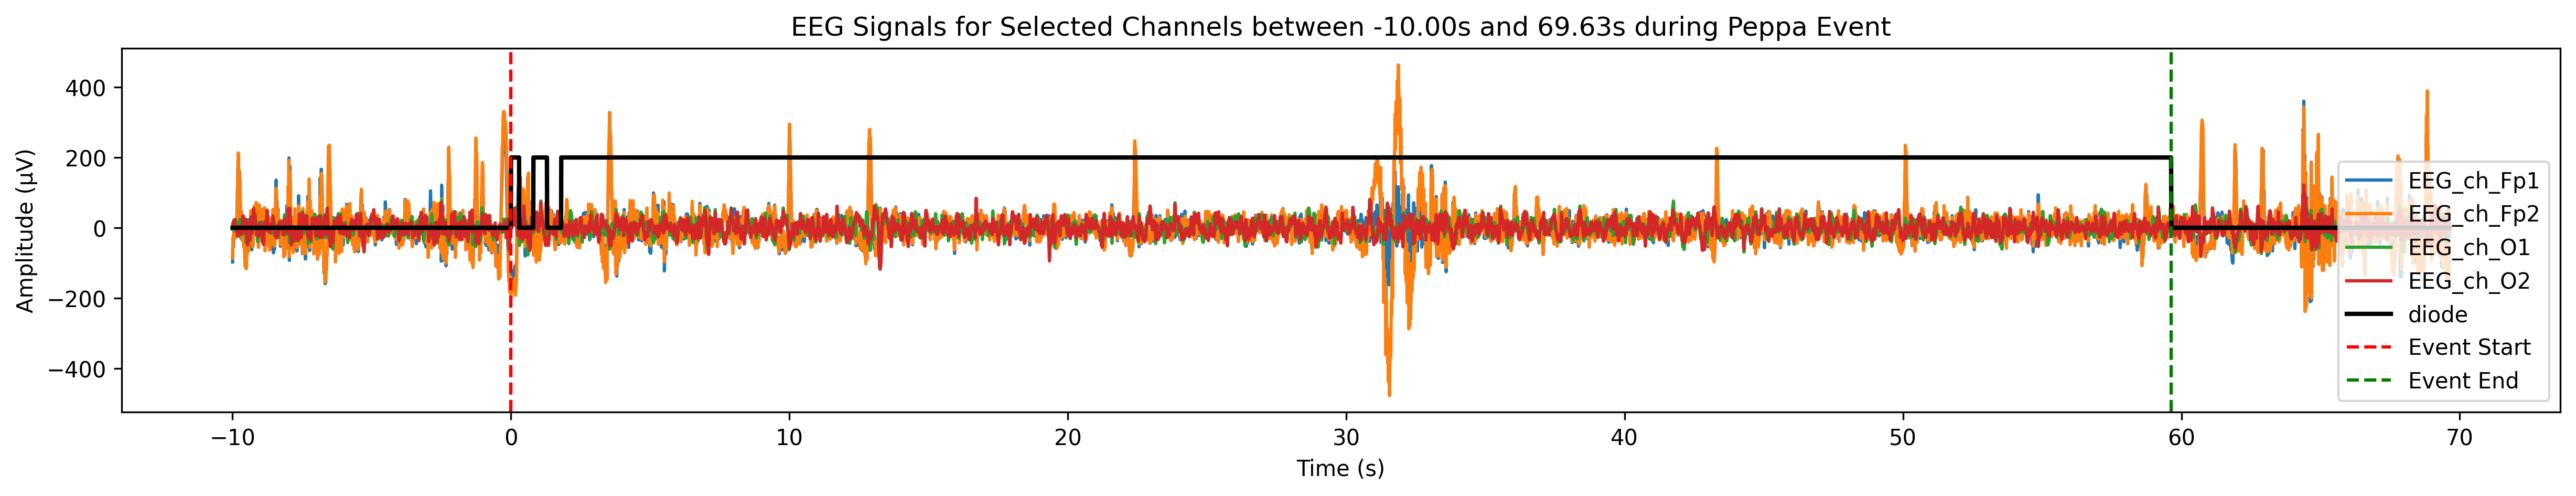

Dyad ID: W_030
Event 'Incredibles' starts at 69.86s and ends at 129.06s
Selected time range with ±10s margin: 59.86s to 139.06s
Retrieved EEG data shape: (10139, 4)


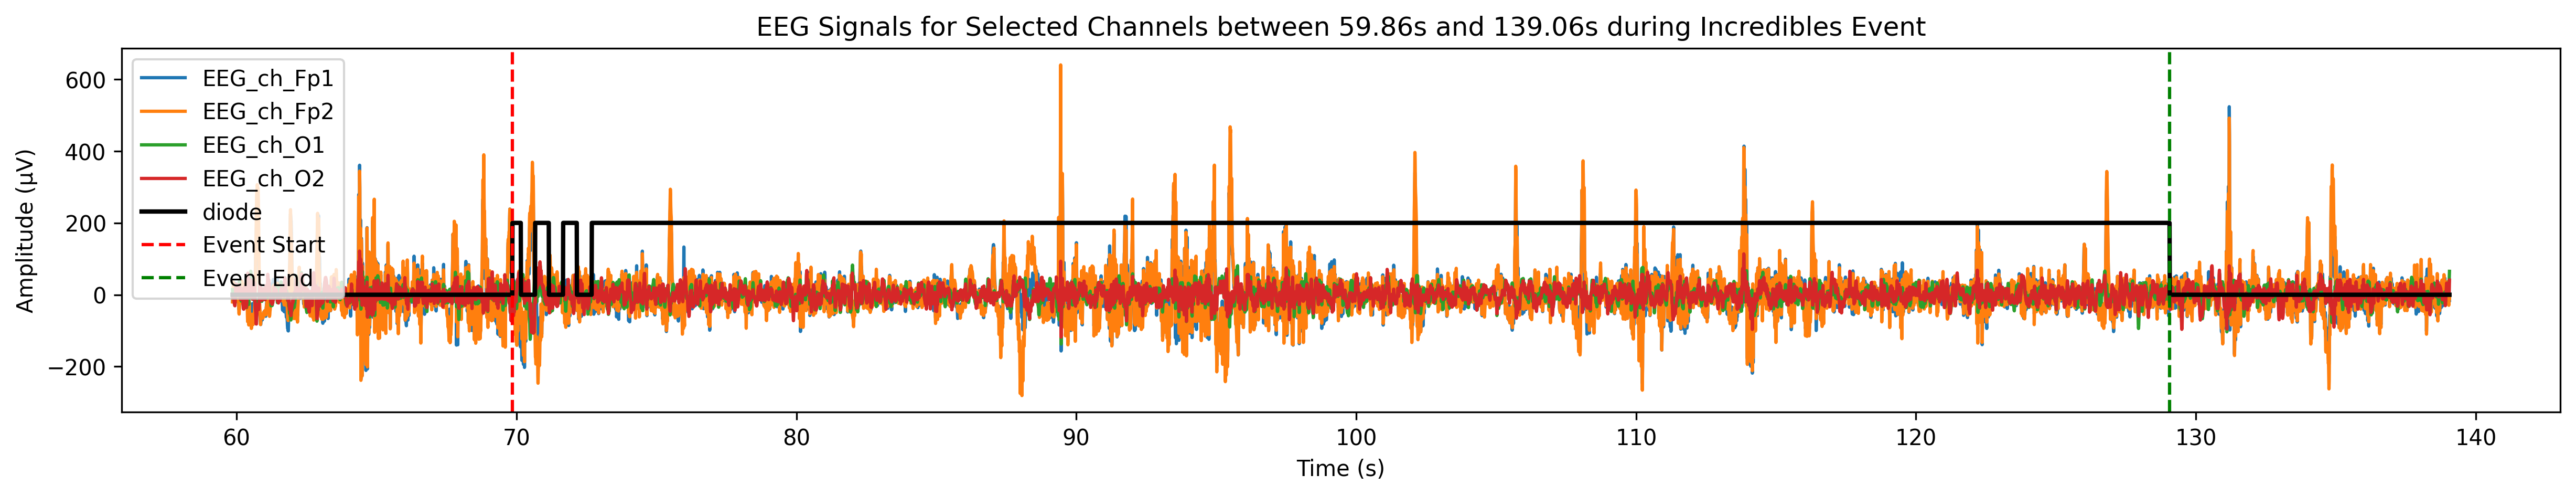

Dyad ID: W_030
Event 'Brave' starts at 139.30s and ends at 198.62s
Selected time range with ±10s margin: 129.30s to 208.62s
Retrieved EEG data shape: (10154, 4)


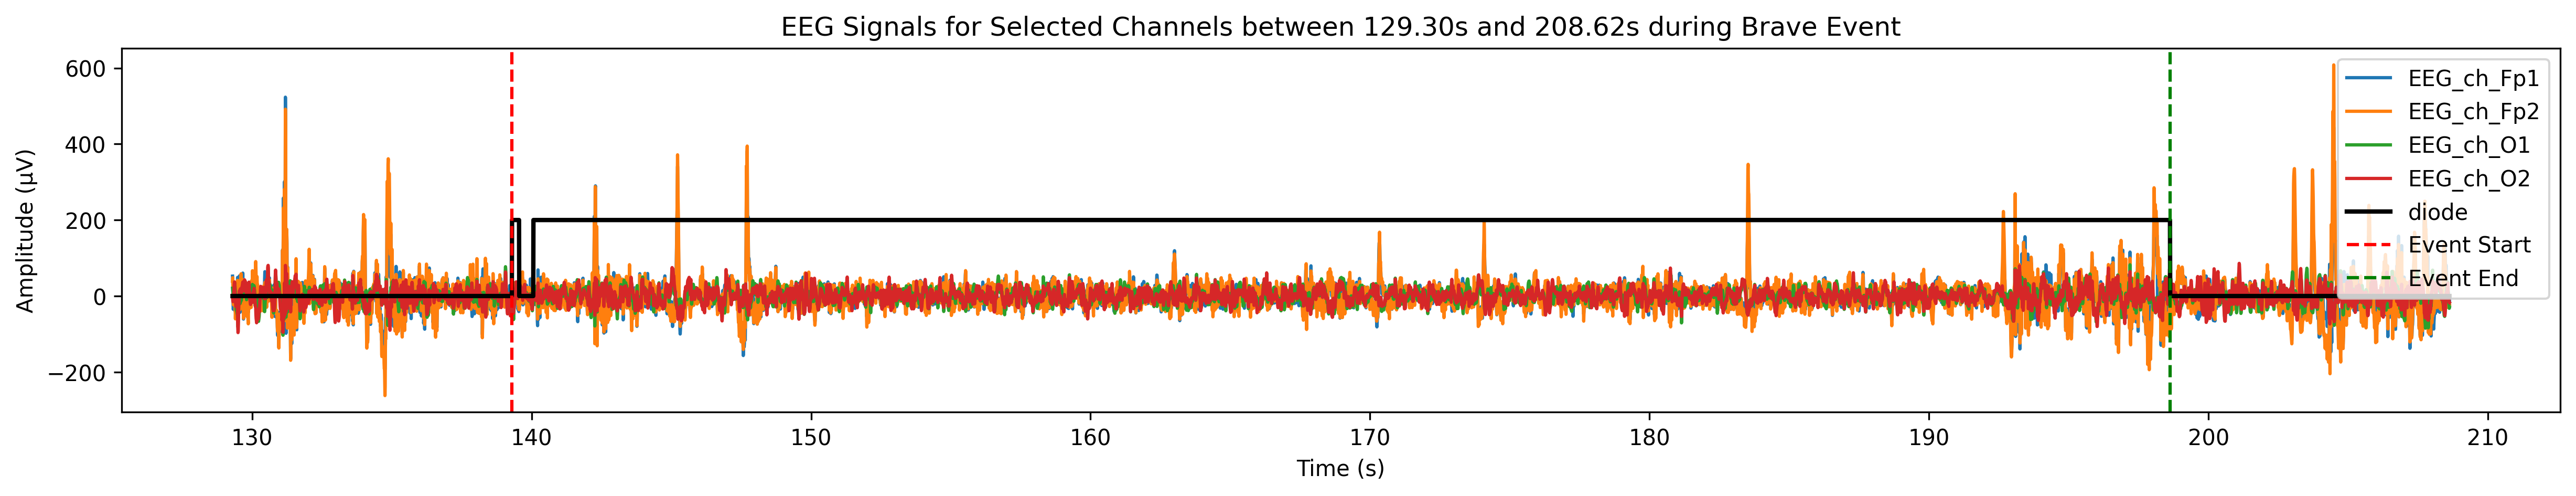

Dyad ID: W_030
Event 'Talk_1' starts at 345.98s and ends at 527.03s
Selected time range with ±10s margin: 335.98s to 537.03s
Retrieved EEG data shape: (25735, 4)


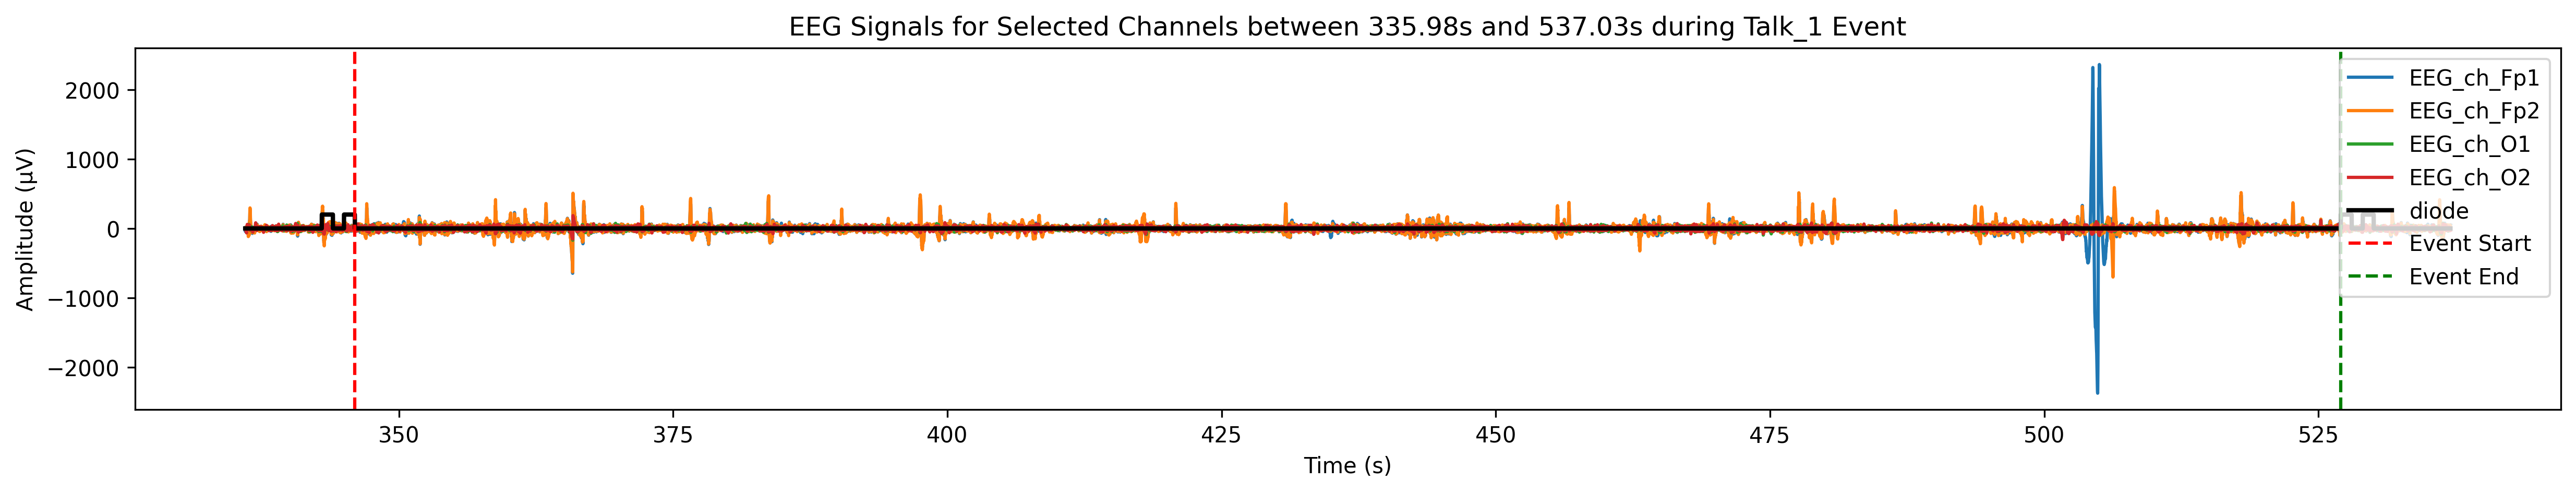

Dyad ID: W_030
Event 'Talk_2' starts at 588.22s and ends at 769.27s
Selected time range with ±10s margin: 578.22s to 779.27s
Retrieved EEG data shape: (25735, 4)


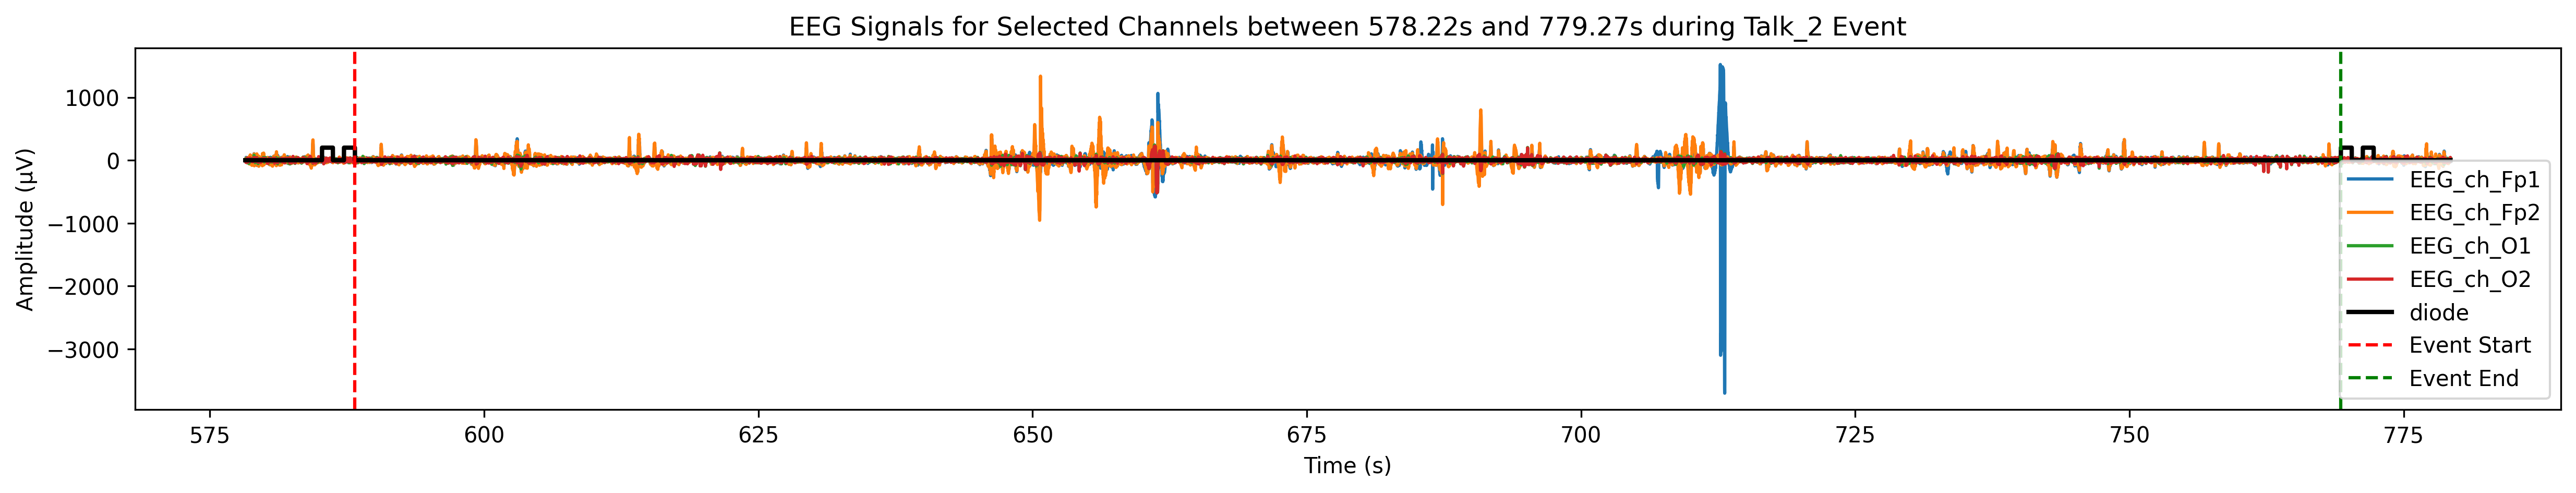

In [6]:
dyad_id = "W_030"# "W_009", "W_030"
multimodal_data = dataloader.create_multimodal_data(data_base_path = "../data", 
                                                    dyad_id = dyad_id, 
                                                    load_eeg=True, 
                                                    load_et=False, 
                                                    load_meta = True,
                                                    lowcut=lowcut, 
                                                    highcut=highcut, 
                                                    eeg_filter_type=eeg_filter_type, 
                                                    interpolate_et_during_blinks_threshold=0.3,
                                                    median_filter_size=64,
                                                    low_pass_et_order=351,
                                                    et_pos_cutoff=128,
                                                    et_pupil_cutoff=4,
                                                    pupil_model_confidence=0.9,
                                                    decimate_factor=q,
                                                    plot_flag=plot_flag)
all_events = list(multimodal_data.events.keys())
print(f"Available events: {all_events}")
for selected_event in all_events:
    plot_data_with_margin(multimodal_data, selected_event = selected_event, time_margin = time_margin, member = member, selected_channels = selected_channels)

# Get the selected data modality for a given event with a time margin on both ends 

Event 'Peppa' starts at 0.00s and ends at 59.63s
Selected time range with ±10s margin: -10.00s to 69.63s
<xarray.DataArray 'signals' (time: 10193, channel: 21)> Size: 2MB
array([[-97.45343738, -86.96670992, -39.96571912, ...,  -7.46349296,
         -3.64278874,   4.18598638],
       [-63.83727717, -51.04182504,  -7.15740011, ...,   4.03579202,
         -0.90178989,  10.29009538],
       [-44.46870042, -26.97990735,   9.66799072, ...,   9.56933148,
          0.55484226,  14.33467437],
       ...,
       [ 35.87007337,  16.18397304,  99.19953259, ...,  36.33018379,
          6.545286  ,  28.11311656],
       [ 31.42515914,  14.1596818 ,  86.91313259, ...,   8.78991711,
         14.57440651,  19.36983259],
       [ -6.84920164, -19.11858389,  56.62972126, ..., -50.31086736,
         10.75835002,  13.97787703]], shape=(10193, 21))
Coordinates:
  * time     (time) float64 82kB -10.0 -9.992 -9.984 ... 69.61 69.62 69.62
  * channel  (channel) <U3 252B 'Fp1' 'Fp2' 'F7' 'F3' ... 'P4' 'T6' 'O1' 

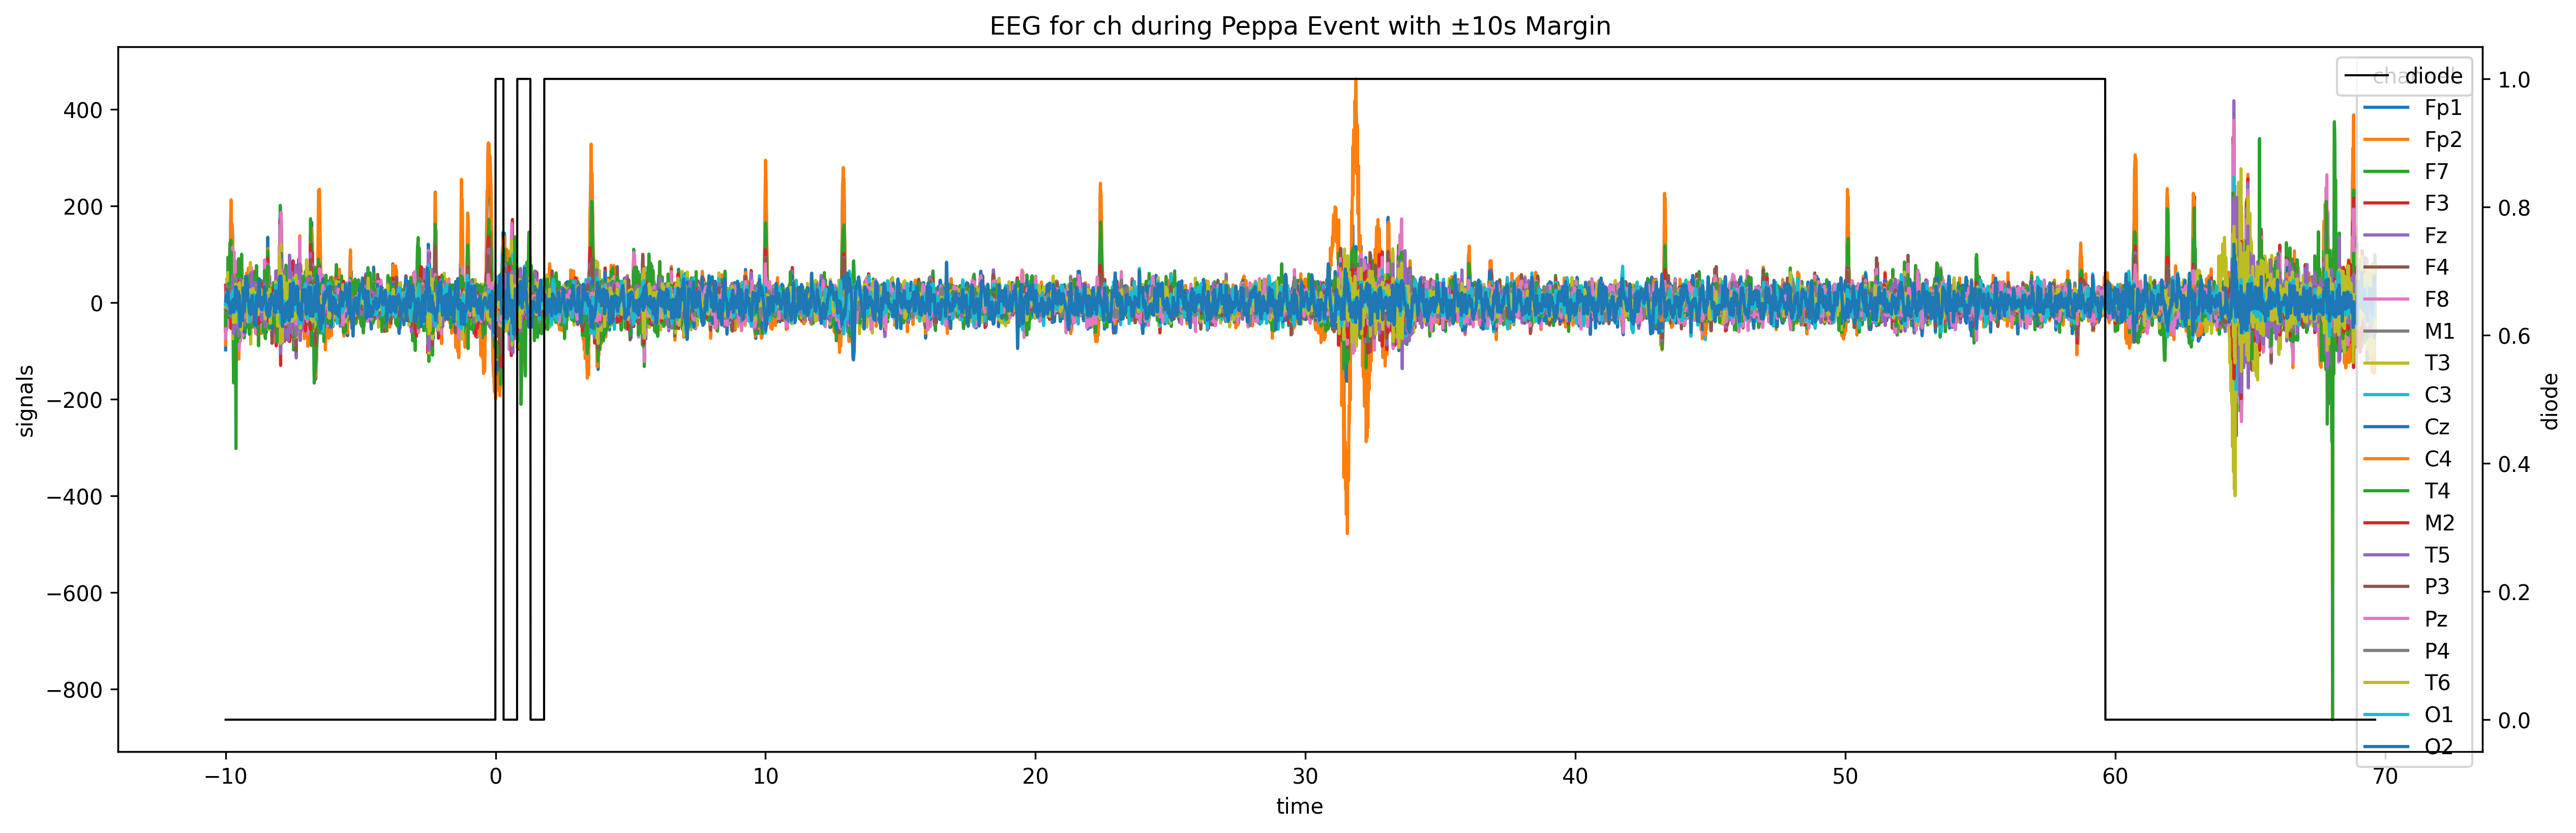

In [9]:
time_margin = 10 # seconds
selected_event =  'Peppa' #'Incredibles' 'Peppa' 'Brave' 'Talk_1' 'Talk_2'
member = 'ch' #'cg'

selected_modality = 'EEG' # choose 'EEG', 'ECG', 'ET', 'IBI', 'RMSSD' or 'diode' for modality to export to xarray (diode is the reference for checking the correctness of event slicing)
selected_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'M1', 'T3', 'C3', 'Cz', 'C4', 'T4', 'M2', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']
#selected_modality = 'ET'
#selected_channels = ['x', 'y', 'pupil', 'blinks']

#selected_modality = 'ECG'
#selected_channels = ['ECG']

#selected_modality = 'IBI'
#selected_channels = ['IBI']

#selected_modality = 'RMSSD'
#selected_channels = ['RMSSD']

#selected_modality = 'diode'
#selected_channels = ['diode']

data_EEG_xr = export_to_xarray(multimodal_data = multimodal_data, 
                               selected_event=selected_event, 
                               selected_channels=selected_channels, 
                               selected_modality=selected_modality, 
                               member=member, 
                               time_margin=time_margin)
# print the xarray DataArray to verify its structure and metadata

print(data_EEG_xr)

data_diode_xr = export_to_xarray(multimodal_data = multimodal_data, 
                               selected_event=selected_event, 
                               selected_channels=selected_channels, 
                               selected_modality='diode', 
                               member=member, 
                               time_margin=time_margin)

# plot the retrieved EEG data using xarray's built-in plotting
fig, ax1 = plt.subplots(figsize=(20, 6), dpi=300)
data_EEG_xr.plot.line(x='time', hue='channel', ax=ax1)
# plot the diode signal for reference with a different scale on the right y-axis    

ax2 = ax1.twinx()
diode_signal = data_diode_xr.squeeze('channel')
ax2.plot(diode_signal['time'], diode_signal.values, color='k', linewidth=1, label='diode')
ax2.set_ylabel('diode')
ax2.legend(loc='upper right')
plt.title(f'{selected_modality} for {member} during {selected_event} Event with ±{time_margin}s Margin')

plt.show()


In [8]:
data_EEG_xr

<xarray.DataArray 'signals' (time: 10193, channel: 21)> Size: 2MB
array([[-97.45343738, -86.96670992, -39.96571912, ...,  -7.46349296,
         -3.64278874,   4.18598638],
       [-63.83727717, -51.04182504,  -7.15740011, ...,   4.03579202,
         -0.90178989,  10.29009538],
       [-44.46870042, -26.97990735,   9.66799072, ...,   9.56933148,
          0.55484226,  14.33467437],
       ...,
       [ 35.87007337,  16.18397304,  99.19953259, ...,  36.33018379,
          6.545286  ,  28.11311656],
       [ 31.42515914,  14.1596818 ,  86.91313259, ...,   8.78991711,
         14.57440651,  19.36983259],
       [ -6.84920164, -19.11858389,  56.62972126, ..., -50.31086736,
         10.75835002,  13.97787703]], shape=(10193, 21))
Coordinates:
  * time     (time) float64 82kB -10.0 -9.992 -9.984 ... 69.61 69.62 69.62
  * channel  (channel) <U3 252B 'Fp1' 'Fp2' 'F7' 'F3' ... 'P4' 'T6' 'O1' 'O2'
Attributes:
    dyad_id:             W_030
    who:                 ch
    sampling_freq:       128.0
    event_name:          Peppa
    event_start:         0.0
    event_duration:      59.625
    time_margin_s:       10.0
    channel_names_csv:   Fp1,Fp2,F7,F3,Fz,F4,F8,M1,T3,C3,Cz,C4,T4,M2,T5,P3,Pz...
    channel_names_json:  ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "M1", "...
    metadata_json:       {"notes": NaN, "child_info": {"age_months": 43.0, "g...